# Assignment 1: Car Listings Data

Welcome to your first required assignment. This notebook will guide you through exploring, cleaning, and transforming a real dataset of car listings from Craigslist.  

Please read these instructions carefully before you begin:

- **AI use**: You may use AI to *ask questions* if you are stuck or need clarification. However, do not use AI code-completion or copy/paste code from AI. The purpose of this assignment is for you to gain fluency with Pandas by writing code yourself.  
- **Questions**: Look for cells marked with `Q:`. These contain questions you must answer, either in code or in Markdown.  
- **Markdown**: Use Markdown cells to explain your results, interpret outputs, and format your answers neatly. Clear communication is part of the assignment.  
- **Output**: Ensure your notebook runs top-to-bottom without errors. Remove stray debug code before submitting.  

By the end of this assignment, you should feel more comfortable working with Pandas and preparing real-world data for analysis. 

When you've finished your work on this notebook, restart the kernel, clear the outputs, and run all cells to ensure everything works as expected. Then commit and push your changes to GitHub. Comment out any cells that are printing large outputs or dataframes.

I've placed blank code cells where you need to write code, but don't feel like you have to do all the work for a given part in a single cell. I like to have each step in its own cell, so I can see the output and check my work as I go. You don't need to write a ton for these answers, fyi.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
listings = pd.read_csv("car_listings.csv")

In [3]:

# Let's handle some column conversions to make it easier to work with this data
listings["time_posted"] = pd.to_datetime(listings["time_posted"], errors="coerce")

# These can have missing values, so cast to pandas' nullable integer type
listings["year"] = pd.to_numeric(listings["year"], errors="coerce").astype("Int64")
listings["odometer"] = pd.to_numeric(listings["odometer"], errors="coerce").astype("Int64")
listings["post_id"] = pd.to_numeric(listings["post_id"], errors="coerce").astype("Int64")
listings["num_images"] = pd.to_numeric(listings["num_images"], errors="coerce").astype("Int64")

listings["price"] = pd.to_numeric(listings["price"], errors="coerce")
listings["latitude"] = pd.to_numeric(listings["latitude"], errors="coerce")
listings["longitude"] = pd.to_numeric(listings["longitude"], errors="coerce")



In [4]:
listings.head

<bound method NDFrame.head of                                                       url     location  \
0       https://fargo.craigslist.org/cto/d/west-fargo-...        fargo   
1       https://chicago.craigslist.org/nwc/cto/d/des-p...      chicago   
2       https://chicago.craigslist.org/nch/cto/d/evans...      chicago   
3       https://chicago.craigslist.org/sox/cto/d/chica...      chicago   
4       https://chicago.craigslist.org/nwi/cto/d/scher...      chicago   
...                                                   ...          ...   
266812  https://chicago.craigslist.org/sox/cto/d/chica...      chicago   
266813  https://chicago.craigslist.org/chc/cto/d/frank...      chicago   
266814  https://chicago.craigslist.org/nwc/cto/d/liber...      chicago   
266815  https://minneapolis.craigslist.org/ram/cto/d/w...  minneapolis   
266816  https://grandrapids.craigslist.org/cto/d/smyrn...  grandrapids   

           post_id               time_posted  \
0       7787882335 2024-09-25 09:

---

### Part 1: Inspect the Data
- Print dataset shape, data types, summary statistics, and missing values.  


In [5]:
# Use this cell to explore the dataset and answer the questions in the assignment.
listings.shape

(266817, 24)

In [6]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266817 entries, 0 to 266816
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   url                266817 non-null  object             
 1   location           266817 non-null  object             
 2   post_id            266817 non-null  Int64              
 3   time_posted        263017 non-null  datetime64[ns, UTC]
 4   name               262666 non-null  object             
 5   make               257869 non-null  object             
 6   model              243707 non-null  object             
 7   year               262668 non-null  Int64              
 8   odometer           262632 non-null  Int64              
 9   title              262670 non-null  object             
 10  paint              193660 non-null  object             
 11  drive              198520 non-null  object             
 12  cylinders          207353 non-

In [7]:
listings.describe()

,post_id,year,odometer,price,num_images,latitude,longitude
count,266817.0,262668.0,262632.0,255654.000000,255956.0,255742.000000,255742.000000
mean,7769245241.054832,2009.254321,152428.71275,9620.251469,11.302009,42.393583,-90.338377
std,67261870.479922,6.304723,165613.707579,10345.793452,5.967262,3.021849,5.321630
min,7525960928.0,1990.0,0.0,500.000000,1.0,-72.895538,-155.901311
25%,7718963797.0,2005.0,100000.0,3671.250000,7.0,41.602800,-93.303637
50%,7772656829.0,2010.0,142796.0,6000.000000,10.0,42.113900,-89.452800
75%,7826911559.0,2014.0,185000.0,11500.000000,15.0,44.674900,-87.929764
max,7878823161.0,2023.0,10000000.0,100000.000000,24.0,76.785337,0.000000


In [8]:
missing_vals = listings.isnull()
print(missing_vals)

          url  location  post_id  time_posted   name   make  model   year  \
0       False     False    False        False  False  False  False  False   
1       False     False    False        False  False  False  False  False   
2       False     False    False        False  False  False  False  False   
3       False     False    False        False  False  False  False  False   
4       False     False    False        False  False  False  False  False   
...       ...       ...      ...          ...    ...    ...    ...    ...   
266812  False     False    False        False  False  False  False  False   
266813  False     False    False        False  False  False  False  False   
266814  False     False    False        False  False  False  False  False   
266815  False     False    False        False  False  False  False  False   
266816  False     False    False        False  False  False  False  False   

        odometer  title  ...   type  transmission  condition    vin  price 

In [9]:
missing_count = listings.isnull().sum()
print(missing_count)

url                       0
location                  0
post_id                   0
time_posted            3800
name                   4151
make                   8948
model                 23110
year                   4149
odometer               4185
title                  4147
paint                 73157
drive                 68297
cylinders             59464
fuel                   4149
type                  48205
transmission           4146
condition             46856
vin                  229840
price                 11163
posting_body_text      3800
title_text             3800
num_images            10861
latitude              11075
longitude             11075
dtype: int64


Q: What does `errors="coerce"` do in the functions above?  

A: <!-- Your answer here -->  converts the data to the requested type but if it can't convert then it places null values

---

Q: How many rows and columns are in this dataset?  

A: <!-- Your answer here -->  266817 rows and 24 columns

---

Q: Which columns have the most missing values?  

A: <!-- Your answer here -->  vin has the most missing values: 229840

---

Q: What data type is used for the `time_posted` column? Why do you think that matters for analysis?  

A: <!-- Your answer here -->  time_posted column uses datetime64[ns, UTC] data types. This matters because it enables proper time based analysis like sorting, filtering by date ranges and extracting time components like day or month for trend analysis and also prevents potentials errors that can arise fromd different string formats or numerical representations.

---

Q: Looking at the summary statistics (`.describe()`), what are the minimum and maximum values for `price` and `odometer`? Do they seem reasonable?  

A: <!-- Your answer here -->  Price: Min = $500.000000, Max = $100000.000000 & Odometer: Min = 0.0 miles, Max = 10000000.0 miles. 
These values are not entirely reasonable. The price range seems acceptable where as the odometer maximum of 10000000.0 miles is unrealistic. 


---

### Part 2: Cleaning
- Drop duplicate rows (`post_id` is unique).  
- Standardize string columns to lowercase.  
- Create new variables:
  - `car_age = 2025 - year`  
  - `high_mileage = odometer > 150000`  
  - `price_per_mile = price / odometer`  


In [10]:
# your code here
listings.drop_duplicates(subset=["post_id"])

,url,location,post_id,time_posted,name,make,model,year,odometer,title,...,type,transmission,condition,vin,price,posting_body_text,title_text,num_images,latitude,longitude
0,https://fargo.craigslist.org/cto/d/west-fargo-...,fargo,7787882335,2024-09-25 09:35:39+00:00,chevy equinox lt awd,chevrolet,equinox,2013,160000,clean,...,SUV,automatic,NaN,NaN,6000.0,\n\nQR Code Link to This Post\n\n\n14 Equinox ...,14 Chevy Equinox,11,46.890700,-96.925800
1,https://chicago.craigslist.org/nwc/cto/d/des-p...,chicago,7789338453,2024-09-30 12:25:28+00:00,ford transit,ford,transit 250 van,2019,93000,clean,...,van,automatic,good,NaN,21900.0,\n\nQR Code Link to This Post\n\n\n2019 Ford C...,2019 FORD TRANSIT 250 VAN,14,42.023580,-87.902577
2,https://chicago.craigslist.org/nch/cto/d/evans...,chicago,7789384937,2024-09-30 14:33:58+00:00,ford escape titanium,ford,escape,2014,122000,clean,...,SUV,automatic,excellent,NaN,6250.0,\n\nQR Code Link to This Post\n\n\n2014 Ford E...,2014 Ford Escape (Excellent condition) Titaniu...,12,42.052098,-87.686005
3,https://chicago.craigslist.org/sox/cto/d/chica...,chicago,7789321782,2024-09-30 11:42:21+00:00,nissan altima 2.5 s,nissan,altima,2015,145000,clean,...,sedan,automatic,excellent,NaN,5200.0,\n\nQR Code Link to This Post\n\n\nHeres is my...,"2015 Nissan Altima S, 145k, *Remote Start*, 4 ...",11,41.781400,-87.770500
4,https://chicago.craigslist.org/nwi/cto/d/scher...,chicago,7789402919,2024-09-30 15:25:31+00:00,honda odyssey touring,honda,odyssey,2007,230000,clean,...,minivan,automatic,excellent,NaN,3500.0,\n\nQR Code Link to This Post\n\n\nVery Nice V...,2007 Honda Odyssey Touring,10,41.492200,-87.460500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266810,https://chicago.craigslist.org/chc/cto/d/evans...,chicago,7645577091,2023-07-20 13:11:03+00:00,2012 land rover range rover sport,land rover,range rover sport,2012,93235,clean,...,SUV,automatic,excellent,SALSK2D40CA742126,13500.0,\n\nQR Code Link to This Post\n\n\nRare opport...,2012 Range Rover Sport HSE LUX Black,6,42.030200,-87.686500
266811,https://chicago.craigslist.org/nwc/cto/d/verno...,chicago,7777942459,2024-08-22 14:24:46+00:00,Chevrolet Express 1500 Cargo,chevrolet,express 1500 cargo,2014,352622,missing,...,van,automatic,fair,1GCSGAFX0E1110269,1200.0,\n\nQR Code Link to This Post\n\n\nChevy expre...,2014 Chevrolet Express 1500,13,42.246220,-87.972255
266813,https://chicago.craigslist.org/chc/cto/d/frank...,chicago,7765750127,2024-07-13 07:05:20+00:00,Jeep Wrangler Unlimited,jeep,wrangler unlimited,2006,51800,clean,...,offroad,automatic,excellent,NaN,23000.0,\n\nQR Code Link to This Post\n\n\n2006 Jeep W...,2006 Jeep Wrangler Unlimited 51k miles Auto clean,23,41.509400,-87.824800
266814,https://chicago.craigslist.org/nwc/cto/d/liber...,chicago,7754969164,2024-06-08 07:08:13+00:00,Jeep Wrangler Unlimited Rubicon,jeep,wrangler unlimited,2010,124000,clean,...,NaN,automatic,good,NaN,15900.0,\n\nQR Code Link to This Post\n\n\n2010 jeep W...,2010 Jeep Wrangler Rubicon 4 Dr,19,42.281000,-87.950000


In [11]:
string_columns = listings.select_dtypes(include=['object']).columns
print(string_columns)

Index(['url', 'location', 'name', 'make', 'model', 'title', 'paint', 'drive',
       'cylinders', 'fuel', 'type', 'transmission', 'condition', 'vin',
       'posting_body_text', 'title_text'],
      dtype='object')


In [12]:
for column in string_columns:
    listings[column] = listings[column].str.lower()
print(listings.head)

<bound method NDFrame.head of                                                       url     location  \
0       https://fargo.craigslist.org/cto/d/west-fargo-...        fargo   
1       https://chicago.craigslist.org/nwc/cto/d/des-p...      chicago   
2       https://chicago.craigslist.org/nch/cto/d/evans...      chicago   
3       https://chicago.craigslist.org/sox/cto/d/chica...      chicago   
4       https://chicago.craigslist.org/nwi/cto/d/scher...      chicago   
...                                                   ...          ...   
266812  https://chicago.craigslist.org/sox/cto/d/chica...      chicago   
266813  https://chicago.craigslist.org/chc/cto/d/frank...      chicago   
266814  https://chicago.craigslist.org/nwc/cto/d/liber...      chicago   
266815  https://minneapolis.craigslist.org/ram/cto/d/w...  minneapolis   
266816  https://grandrapids.craigslist.org/cto/d/smyrn...  grandrapids   

           post_id               time_posted  \
0       7787882335 2024-09-25 09:

In [13]:
listings["car_age"] = 2025 - listings["year"]
listings["high_mileage"] = listings["odometer"] > 150000
listings["price_per_mile"] = listings["price"] / listings["odometer"]

In [14]:
group = listings.groupby(['make','model'])
result = group.agg({"high_mileage":["count","mean"]})
result = result[result[("high_mileage","count")] >= 100]
result = result.sort_values(('high_mileage', 'mean'), ascending=False)
print(result.head())

                        high_mileage          
                               count      mean
make      model                               
toyota    sequoia                532  0.815789
ford      excursion              271  0.815498
chevrolet suburban 1500          150  0.813333
toyota    land cruiser           108  0.796296
nissan    xterra                 217  0.788018


In [15]:
make_median = listings.groupby("make")["price_per_mile"].median().sort_values(ascending=False)
print(make_median.head())

make
lamborghini     5.00447
lucid          4.936709
rivian          4.68008
polestar       2.896572
ferrari        1.713953
Name: price_per_mile, dtype: Float64


Q: After standardizing the string columns (`make`, `model`, `fuel`, `drive`, etc.), why is it helpful to convert everything to lowercase?  

A: <!-- Your answer here -->  It ensures consistency for analysis and filtering. 

---

Q: You created a new variable `car_age = 2025 - year`. Why might this be helpful?   

A: <!-- Your answer here -->  It gives you depreciation value of the car. Also helps to understand how age affects price, condition and other factors.

---

Q: You created a flag `high_mileage = odometer > 150000`. What make/model with at least 100 observations has the highest proportion of listings in this category?  

A: <!-- Your answer here -->  toyota sequoia has the highest proportion of listing in high_mileage category with 81.58% with 532 observation.

---

Q: You created a new variable `price_per_mile = price / odometer`. Which make has the highest **median** value for this new variable? Do you think this statistic is meaningful? Why or why not?  

A: <!-- Your answer here --> Lamborghini has the highest median price_per_mile value at $5.00 per mile.


---

### Part 3: Exploration

For this next section, cut down the data to just Ford F-150s. Call this data frame `ford_150s`. Then:
- Fill missing values:
  - Numeric (`odometer`, `year`, `price`) with median.  
  - Categorical (`fuel`, `drive`, `transmission`, `paint`) with the most common value (the "mode").  
- Filter listings priced between $5,000 and $50,000.  
- Compute average price by location.  
- Count monthly listings using `time_posted`.  


In [16]:
# Your code here
ford_150s = listings[(listings["make"] == "ford") & (listings["model"] == "f150")].copy()
ford_150s.shape

(7934, 27)

In [17]:
odometer_median = ford_150s["odometer"].median()
year_median = ford_150s["year"].median()
price_median = ford_150s["price"].median()
print(f'odometer median -> {odometer_median}, year_median -> {year_median}, price_median -> {price_median}')

odometer median -> 157000.0, year_median -> 2010.0, price_median -> 7500.0


In [18]:
print(ford_150s["odometer"].skew())
print(ford_150s["year"].skew())
print(ford_150s["price"].skew())

13.284146618398843
-0.4485839673856295
2.338065170291875


In [19]:
fuel_mode = ford_150s["fuel"].mode()[0]
drive_mode = ford_150s["drive"].mode()[0]
transmission_mode = ford_150s["transmission"].mode()[0]
paint_mode = ford_150s["paint"].mode()[0]
print(f'fuel mode -> {fuel_mode}, drive_mode -> {drive_mode}, transmission_mode -> {transmission_mode}, paint_mode -> {paint_mode}')

fuel mode -> gas, drive_mode -> 4wd, transmission_mode -> automatic, paint_mode -> white


In [20]:
ford_150s["odometer"] = ford_150s["odometer"].fillna(odometer_median)
ford_150s["year"] = ford_150s["year"].fillna(year_median)
ford_150s["price"] = ford_150s["price"].fillna(price_median)

In [21]:
ford_150s["fuel"] = ford_150s["fuel"].fillna(fuel_mode)
ford_150s["drive"] = ford_150s["drive"].fillna(drive_mode)
ford_150s["transmission"] = ford_150s["transmission"].fillna(transmission_mode)
ford_150s["paint"] = ford_150s["paint"].fillna(paint_mode)

In [22]:
print("Missing values after filling:")
print(ford_150s[["odometer", "year", "price", "fuel", "drive", "transmission", "paint"]].isnull().sum())

Missing values after filling:
odometer        0
year            0
price           0
fuel            0
drive           0
transmission    0
paint           0
dtype: int64


In [23]:
ford_150s = ford_150s[(ford_150s["price"]>=5000) & (ford_150s["price"] <= 50000)]
ford_150s.head()

,url,location,post_id,time_posted,name,make,model,year,odometer,title,...,vin,price,posting_body_text,title_text,num_images,latitude,longitude,car_age,high_mileage,price_per_mile
68,https://appleton.craigslist.org/cto/d/neenah-2...,appleton,7789188615,2024-09-29 20:27:41+00:00,ford f-150,ford,f150,2016,115000,clean,...,1ftew1eg6gke09652,25000.0,\n\nqr code link to this post\n\n\nup for sale...,2016 ford f-150 super-crew 4x4,24,44.18110,-88.479200,9,False,0.217391
111,https://chicago.craigslist.org/nch/cto/d/wilme...,chicago,7781853684,2024-09-04 16:41:32+00:00,ford f-150 xl 4x4,ford,f150,2014,55000,clean,...,1ftnf1efxekd32949,10900.0,\n\nqr code link to this post\n\n\n14 ford f-1...,2014 ford f-150 4x4 long bed original 55k mile...,13,42.06273,-87.751856,11,False,0.198182
129,https://milwaukee.craigslist.org/cto/d/new-ber...,milwaukee,7790067892,2024-10-02 20:31:32+00:00,ford f-150,ford,f150,2008,138500,clean,...,NaN,7500.0,\n\nqr code link to this post\n\n\nlocking lak...,2008 ford f150 xlt 4x4,4,42.98220,-88.094600,17,False,0.054152
151,https://stlouis.craigslist.org/cto/d/greenvill...,stlouis,7769529379,2024-07-25 20:58:03+00:00,ford f150 lariat 4x4,ford,f150,2012,146500,clean,...,NaN,16500.0,\n\nqr code link to this post\n\n\nexcellent c...,2012 ford f-150 lariat supercrew 4x4 excellent,20,38.89330,-89.405200,13,False,0.112628
186,https://minneapolis.craigslist.org/wsh/cto/d/s...,minneapolis,7878590788,2025-09-02 18:11:34+00:00,ford f-150,ford,f150,2008,202400,lien,...,NaN,6500.0,\n\nqr code link to this post\n\n\n2008 ford f...,2008 ford f150,6,45.13310,-92.686500,17,True,0.032115


In [24]:
avg_price_by_location = ford_150s.groupby("location")["price"].mean().sort_values(ascending=False)
print(f'Average price by location: {avg_price_by_location}')

Average price by location: location
duluth         17837.657534
fargo          15047.025974
kansascity     14699.711712
omaha          14543.837838
appleton       14524.359375
desmoines      14195.623431
madison        14183.357447
stlouis        13937.512777
grandrapids    13895.377990
minneapolis    13403.672978
chicago        11554.263787
milwaukee      11214.558621
Name: price, dtype: float64


In [25]:
ford_150s.shape

(5445, 27)

In [26]:
ford_150s["year_month"] = ford_150s["time_posted"].dt.to_period('M')
monthly_counts = ford_150s["year_month"].value_counts().sort_index()
print(monthly_counts)

year_month
2023-06      8
2023-07    146
2023-08    171
2023-09    134
2023-10    142
2023-11    135
2023-12     87
2024-01     99
2024-02    158
2024-03    201
2024-04    239
2024-05    270
2024-06    410
2024-07    253
2024-08    284
2024-09    261
2024-10    310
2024-11    228
2024-12    194
2025-01    203
2025-02    187
2025-03    237
2025-04    230
2025-05    240
2025-06    202
2025-07    191
2025-08    212
2025-09     13
Freq: M, Name: count, dtype: int64


/var/folders/cz/lb9k3krn429_0k0v335n5kbw0000gn/T/ipykernel_10600/374161245.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ford_150s["year_month"] = ford_150s["time_posted"].dt.to_period('M')


Q: After filtering to Ford F-150s, how many rows remain in your dataset?  

A: <!-- Your answer here -->  7934 rows

---

Q: When filling missing numeric values with the median, why might that be a better choice than the mean for this dataset?  

A: <!-- Your answer here -->  Using the median instead of the mean to fill numeric values is better when the dataset is skewed or contains outliers. The median provides a more robust central estimate. Since the Odometer, year and price are all skewed, so it may contain outliers, making median would be better.

---

Q: When filling missing categorical values with the mode, what potential problems could arise?  

A: <!-- Your answer here -->  Because filling with the mode can overrepresent the most common category, reduce variablity in the data and make the dataset more imbalanced and make the model bias.

---

Q: After filtering to prices between $5,000 and $50,000, what is the new row count?  

A: <!-- Your answer here -->  5445 rows

---

Q: Which location has the highest average price for Ford F-150s? Does that result surprise you?  

A: <!-- Your answer here -->  Duluth has the highest average price for F-150s at $17,837.66. This is a bit surprising, as I would have expected Chicago or Minneapolis to be more expensive due to their larger markets. Duluth is smaller city. So, maybe Duluth's harsh winters create high demand for F-150s and being a smaller cities it might have lesser dealership or seller.

---

Q: Looking at the monthly counts of listings, do you notice any seasonal patterns or anomalies?  

A: <!-- Your answer here --> The monthly listings for June show a big contrast: June 2023 had only 8 listings, while June 2024 peaked at 410 listings. This huge difference suggests that the 2023 data may be incomplete or underreported. Overall, listings tend to increase during spring and summer months, with fall and winter generally having fewer listings.



---
### Part 4: Visualization

We will cover visualization next week, so here's some code that makes plots for you based on the cleaned data you made in the previous section. 

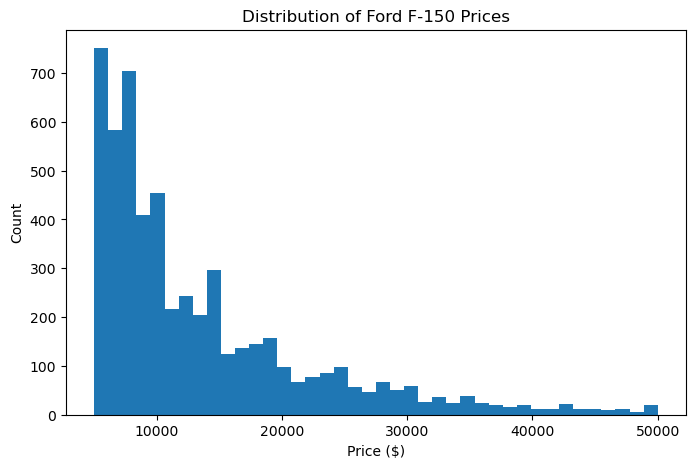

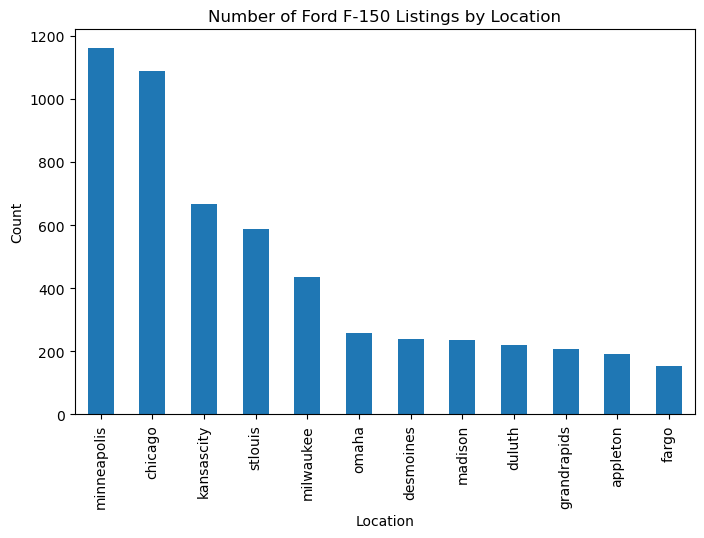

<Figure size 1000x600 with 0 Axes>

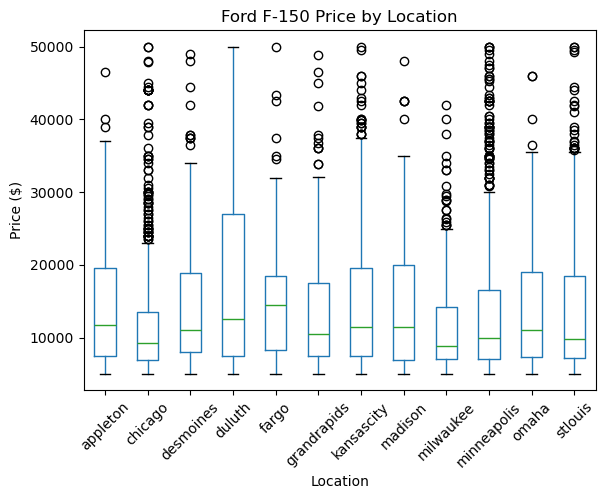

In [46]:

# Histogram of prices
ford_150s["price"].plot.hist(bins=40, figsize=(8,5))
plt.title("Distribution of Ford F-150 Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

# Bar chart of listings by location
ford_150s["location"].value_counts().plot.bar(figsize=(8,5))
plt.title("Number of Ford F-150 Listings by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

# Boxplot of price by location
plt.figure(figsize=(10,6))
ford_150s.boxplot(column="price", by="location", grid=False, rot=45)
plt.title("Ford F-150 Price by Location")
plt.suptitle("")  # Remove that default subtitle
plt.xlabel("Location")
plt.ylabel("Price ($)")
plt.show()

Q: Looking at the histogram, what do you notice about the distribution of prices? Are there any unusual features?  

A: <!-- Your answer here -->  The price distribution is skewed to the right side, with most clustered in the $5,000 to $15,000 range. The distribution drops off sharply after $20,000, with very few vehicles above $30,000. 

---

Q: Do the counts of listings by location make sense to you? 

A: <!-- Your answer here --> Yes, the listing counts generally align with what one would expect based on metropolitan area population sizes. Minneapolis and Chicago have the most listings as major urban areas. Mid-sized cities, such as Kansas City, St. Louis, and Milwaukee, fall within the middle range. Smaller markets like Duluth, Grand Rapids, Appleton, and Fargo have proportionally fewer listings, which matches their smaller populations and market reach. This distribution makes sense as larger cities have more people, more dealerships.

---

Q: Do the plots help you understand the data differently than the summary statistics alone? Explain briefly.  

A: <!-- Your answer here -->  Yes, the summary statistics showed Duluth had the highest average price, but the boxplot reveals this is based on a much smaller sample size with less price variation. The boxplots show that some locations have much wider price ranges than others, which you can't see from just looking at average prices alone.

--- 

Q: What do you notice about the distribution of prices by location?
A: <!-- Your answer here -->  There's significant variation across locations. Smaller markets (Duluth, Fargo) tend to have higher median prices and tighter distributions, while larger markets (Chicago, Minneapolis) show more price variability. 

---

Q: Which location shows the widest spread of prices? What might that indicate about the market in that city?  

A: <!-- Your answer here -->  
A: Minneapolis and Chicago show the widest price spreads, with extensive outliers. This indicates diverse, mature markets with vehicles across all age/condition segments.

---

Q: Do you see any extreme outliers in the boxplots? How might those affect your analysis?  

A: <!-- Your answer here -->  Yes, every location has high-priced outliers ($40,000-$50,000), with Minneapolis and Chicago having the most extensive outlier patterns. However, Duluth notably has no outliers. This suggests Duluth's entire price distribution appears to be shifted higher, suggesting consistently higher prices across all F-150s in that market. 


---

### Part 5: Reflection

- Write a short reflection in Markdown:
  - What was most challenging about cleaning this dataset?  
  - Did anything surprise you?

 There wasn't much of a technical challenge since the instructions were clear and I just followed along. The only minor confusion was figuring out whether to create new variables like car_age = 2025 - year as Python variables or pandas DataFrame columns, but I worked that out quickly. I also had to revise my understanding of boxplots since I'd forgotten how to interpret them properly.

 Duluth, having the highest average F-150 price, was surprising until I researched and learned it's a small northern Minnesota city with harsh winters. This made me realize the real challenge in data analysis isn't the technical cleaning but understanding the context behind your results. You need domain knowledge to interpret whether findings make sense. The data tells you what happened, but understanding why requires knowing the real-world context.

